**PROJECT  TITLE:**


**Job Salary Prediction Using Machine Learning**

**Project Objective**

To develop a machine learning model that predicts employee salaries based on job title, experience, education, skills, industry, company size, location, remote work, and certifications.

In [ ]:
#steps

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [3]:
df = pd.read_csv("/content/salary_prediction_dataset.csv")

**Display Dataset**

In [5]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,Software Engineer,1,1,4,IT,100,Delhi,1,1,42000
1,Data Analyst,2,2,5,Finance,200,Mumbai,0,2,50000
2,Software Engineer,3,2,6,IT,150,Delhi,1,2,58000
3,Project Manager,8,3,8,IT,500,Bangalore,0,3,95000
4,Data Scientist,5,3,9,Healthcare,300,Pune,1,4,90000


In [6]:
df.tail()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
25,Data Scientist,9,3,11,Healthcare,650,Hyderabad,1,5,108000
26,Project Manager,13,3,14,IT,1200,Bangalore,0,7,150000
27,Business Analyst,4,2,7,Finance,300,Mumbai,0,3,70000
28,Software Engineer,8,3,10,IT,700,Delhi,1,5,112000
29,Data Analyst,2,1,5,Finance,190,Pune,1,2,53000


In [7]:
df.shape

(30, 10)

In [8]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_title         30 non-null     object
 1   experience_years  30 non-null     int64 
 2   education_level   30 non-null     int64 
 3   skills_count      30 non-null     int64 
 4   industry          30 non-null     object
 5   company_size      30 non-null     int64 
 6   location          30 non-null     object
 7   remote_work       30 non-null     int64 
 8   certifications    30 non-null     int64 
 9   salary            30 non-null     int64 
dtypes: int64(7), object(3)
memory usage: 2.5+ KB


**Statistical Summary**

In [10]:
df.describe()

,experience_years,education_level,skills_count,company_size,remote_work,certifications,salary
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.00000,30.0000
mean,5.866667,2.266667,8.300000,462.333333,0.533333,3.40000,84900.0000
std,3.370596,0.784915,2.914293,296.562877,0.507416,1.67332,30724.9758
min,1.000000,1.000000,4.000000,100.000000,0.000000,1.00000,42000.0000
25%,3.000000,2.000000,6.000000,202.500000,0.000000,2.00000,58250.0000
50%,5.500000,2.000000,8.000000,425.000000,1.000000,3.00000,81500.0000
75%,8.000000,3.000000,10.750000,687.500000,1.000000,5.00000,107250.0000
max,13.000000,3.000000,14.000000,1200.000000,1.000000,7.00000,150000.0000


**Check Missing Values**

In [11]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


**Check Duplicate Records**

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(30, 10)

**Check Data Types**

In [14]:
df.dtypes

,0
job_title,object
experience_years,int64
education_level,int64
skills_count,int64
industry,object
company_size,int64
location,object
remote_work,int64
certifications,int64
salary,int64


**EDA (Exploratory Data Analysis)**

**Salary Distribution**

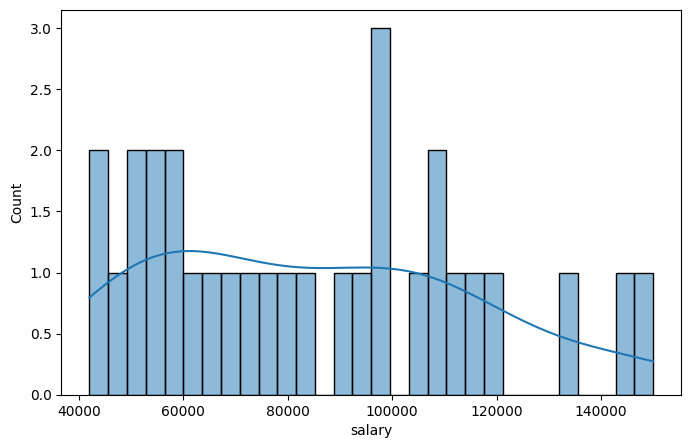

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary"],bins=30,kde=True)
plt.show()

**Interpretation:**

*The salary distribution is approximately bell-shaped, with most employees earning between ₹120,000 and ₹170,000, while very low and very high salaries are less common.*


**Experience Distribution**

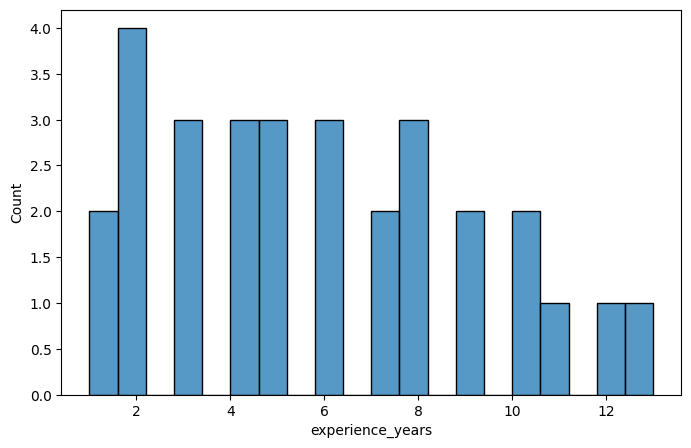

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["experience_years"],bins=20)
plt.show()

**Interpretation:**

*Employee experience ranges from 0 to 20 years, with the highest number of employees having around 20 years of experience.*

**Education Level Count**

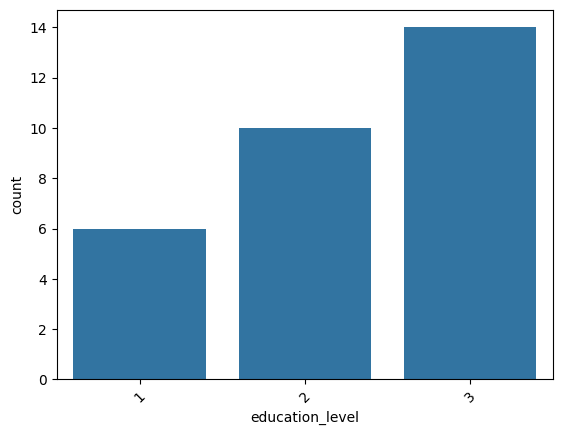

In [17]:
sns.countplot(x="education_level",data=df)
plt.xticks(rotation=45)
plt.show()

**Interpretation:**

*The number of employees is almost equally distributed across all education levels, with no education category significantly larger than the others.*


**Industry Count**

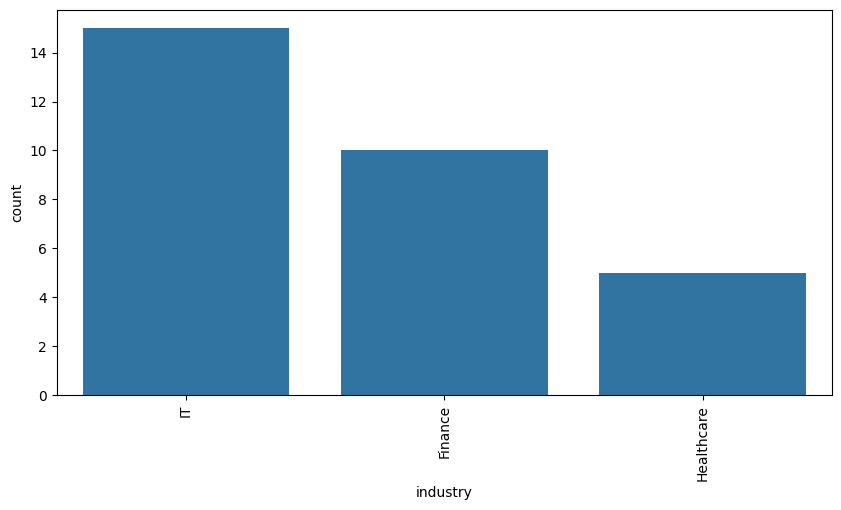

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(x="industry",data=df)
plt.xticks(rotation=90)
plt.show()

**Interpretation:**

*Employees are distributed almost evenly across all industries, indicating a balanced representation of different sectors in the dataset.*

**Company Size Count**

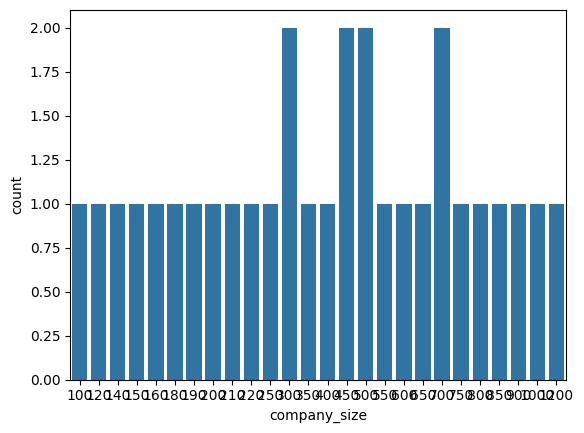

In [19]:
sns.countplot(x="company_size",data=df)
plt.show()

**Interpretation:**

*Employees are almost equally distributed across different company sizes, indicating a balanced dataset with no dominant company size.*

**Remote Work Distribution**

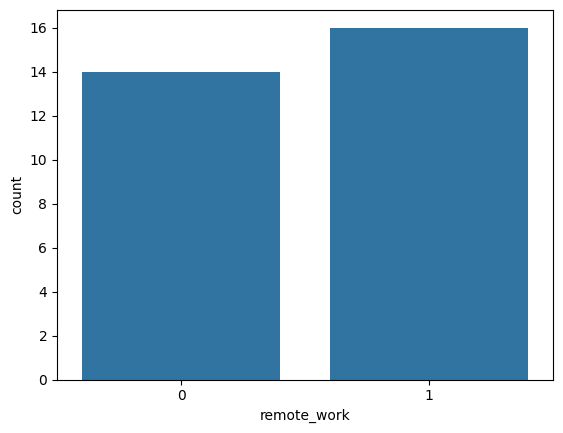

In [20]:
sns.countplot(x="remote_work",data=df)
plt.show()

**Interpretation:**

*The numbers of employees working remotely, in hybrid mode, and on-site are nearly equal, showing a balanced distribution of work modes.*

**Experience vs Salary**

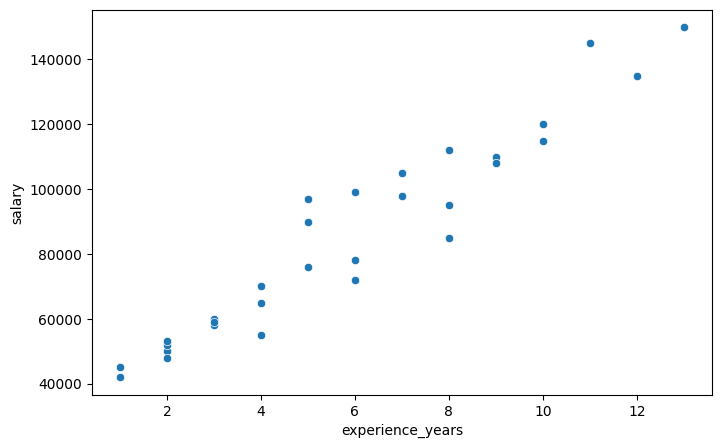

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="experience_years",y="salary",data=df)
plt.show()

**Interpretation:**

*The scatter plot shows a positive relationship between experience and salary, indicating that employees with more years of experience generally earn higher salaries.*

**Data Preprocessing**

**Encode Categorical Columns**

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [23]:
df["job_title"]=le.fit_transform(df["job_title"])

In [24]:
df["education_level"]=le.fit_transform(df["education_level"])

In [25]:
df["industry"]=le.fit_transform(df["industry"])

In [26]:
df["company_size"]=le.fit_transform(df["company_size"])

In [27]:
df["location"]=le.fit_transform(df["location"])

In [28]:
df["remote_work"]=le.fit_transform(df["remote_work"])

**Check Encoded Data**

In [29]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,4,1,0,4,2,0,1,1,1,42000
1,1,2,1,5,0,7,3,0,2,50000
2,4,3,1,6,2,3,1,1,2,58000
3,3,8,2,8,2,15,0,0,3,95000
4,2,5,2,9,1,11,4,1,4,90000


**Correlation Matrix**

In [30]:
df.corr(numeric_only=True)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
job_title,1.000000,0.157441,0.212484,0.234118,0.955023,0.094466,-0.783871,0.209165,0.122324,0.226504
experience_years,0.157441,1.000000,0.795933,0.934480,0.366092,0.945060,-0.536557,-0.582006,0.926863,0.960482
education_level,0.212484,0.795933,1.000000,0.883372,0.368958,0.836962,-0.442606,-0.369406,0.861141,0.864768
skills_count,0.234118,0.934480,0.883372,1.000000,0.408291,0.936745,-0.511626,-0.461710,0.964504,0.971192
industry,0.955023,0.366092,0.368958,0.408291,1.000000,0.292879,-0.910446,0.024815,0.293465,0.423536
company_size,0.094466,0.945060,0.836962,0.936745,0.292879,1.000000,-0.468806,-0.637934,0.919870,0.942804
location,-0.783871,-0.536557,-0.442606,-0.511626,-0.910446,-0.468806,1.000000,0.252244,-0.408279,-0.553774
remote_work,0.209165,-0.582006,-0.369406,-0.461710,0.024815,-0.637934,0.252244,1.000000,-0.462981,-0.480846
certifications,0.122324,0.926863,0.861141,0.964504,0.293465,0.919870,-0.408279,-0.462981,1.000000,0.961925
salary,0.226504,0.960482,0.864768,0.971192,0.423536,0.942804,-0.553774,-0.480846,0.961925,1.000000


**Heatmap**

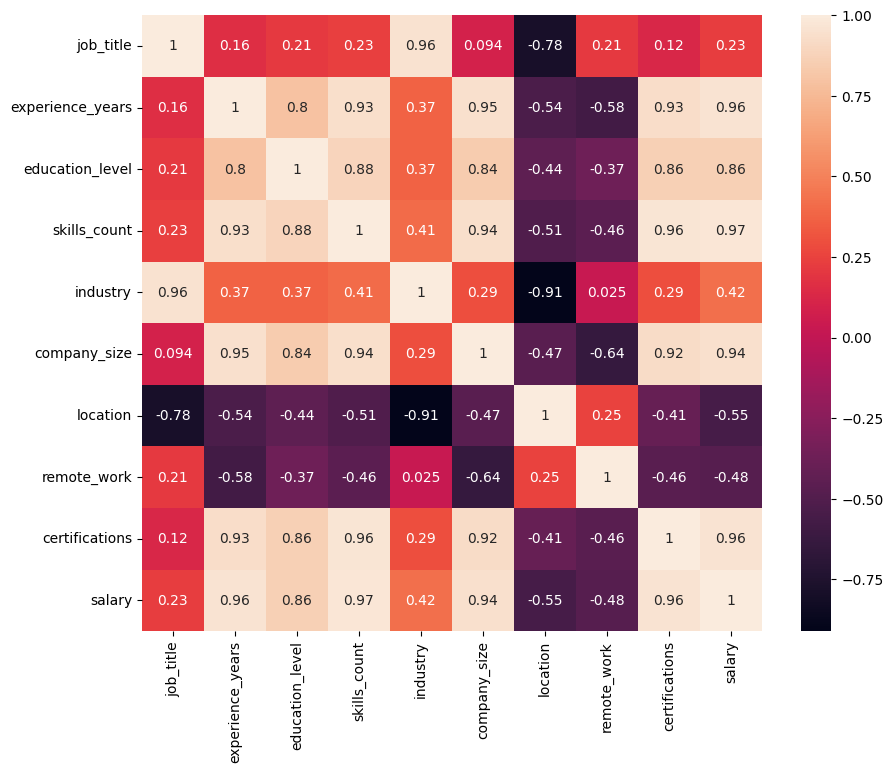

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

**Interpretation:**

*The heatmap shows that experience_years has the strongest positive correlation with salary (0.44), while company_size has a moderate negative correlation (-0.40). Most other features have weak correlations with salary*

**Feature Selection**

In [32]:
# define x and y
x = df.drop("salary",axis=1) #(independent var) remove dependent var from data frame

In [33]:
y=df["salary"]  # dependend var

**Train-Test Split**

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

**Model 1: Linear Regression**

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
lin_reg = LinearRegression()

In [38]:
lin_reg.fit(x_train,y_train)

LinearRegression()

**Prediction**

In [39]:
y_pred_lin_reg = lin_reg.predict(x_test)

**Evaluation**

In [40]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [41]:
print("MAE:",mean_absolute_error(y_test,y_pred_lin_reg))

MAE: 4986.340246967172


In [42]:
print("MSE:",mean_squared_error(y_test,y_pred_lin_reg))

MSE: 32907618.267163973


In [43]:
print("R2 Score:",r2_score(y_test,y_pred_lin_reg))

R2 Score: 0.9395697685361201


**Model 2: Decision Tree**

In [44]:
from sklearn.tree import DecisionTreeRegressor

In [45]:
dt_reg=DecisionTreeRegressor()
dt_reg.fit(x_train,y_train)

DecisionTreeRegressor()

**Prediction**

In [46]:
y_pred_dt_reg = dt_reg.predict(x_test)

**Evaluation**

In [47]:
print("R2 Score:",r2_score(y_test,y_pred_dt_reg))

R2 Score: 0.8870638645174455


**Model 3: Random Forest**

In [48]:
from sklearn.ensemble import RandomForestRegressor

In [49]:
rf_reg = RandomForestRegressor()

In [50]:
rf_reg.fit(x_train,y_train)

RandomForestRegressor()

**Prediction**

In [51]:
y_pred_rf_reg = rf_reg.predict(x_test)

**Evaluation**

In [52]:
print("R2 Score:",r2_score(y_test,y_pred_rf_reg))

R2 Score: 0.9687462558661497


**Cmparision of Modeles**

In [53]:
print("Linear REgression:",r2_score(y_test,y_pred_lin_reg))
print("Decision Tree:",r2_score(y_test,y_pred_dt_reg))
print("Random Forest:",r2_score(y_test,y_pred_rf_reg))

Linear REgression: 0.9395697685361201
Decision Tree: 0.8870638645174455
Random Forest: 0.9687462558661497


**Evaluation Metrics (Best Model)**

In [54]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error

print("MAE :", mean_absolute_error(y_test, y_pred_rf_reg))
print("MSE :", mean_squared_error(y_test, y_pred_rf_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_reg)))
print("R2 Score:", r2_score(y_test, y_pred_rf_reg))

MAE : 3003.3333333333335
MSE : 17019400.0
RMSE: 4125.457550381533
R2 Score: 0.9687462558661497


**Actual vs Predicted Salary**

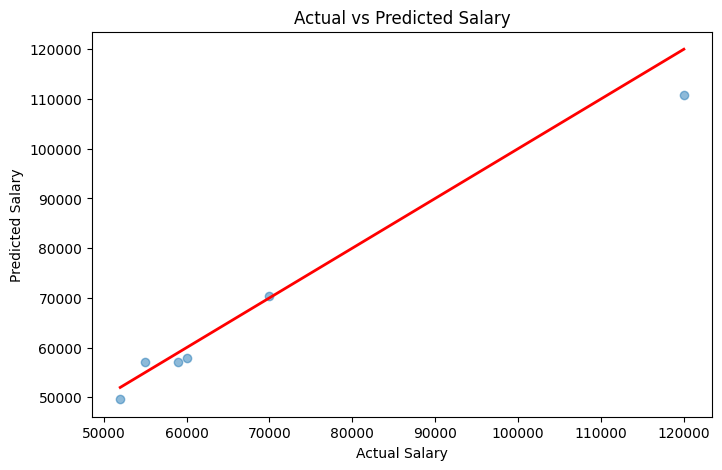

In [55]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred_rf_reg,alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red', linewidth=2)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

**Interpretation:**

*The scatter plot compares the actual and predicted salary values. Most data points lie close to the red reference line, indicating that the Random Forest model predicts employee salaries with high accuracy and minimal error.*

**Feature Importance**

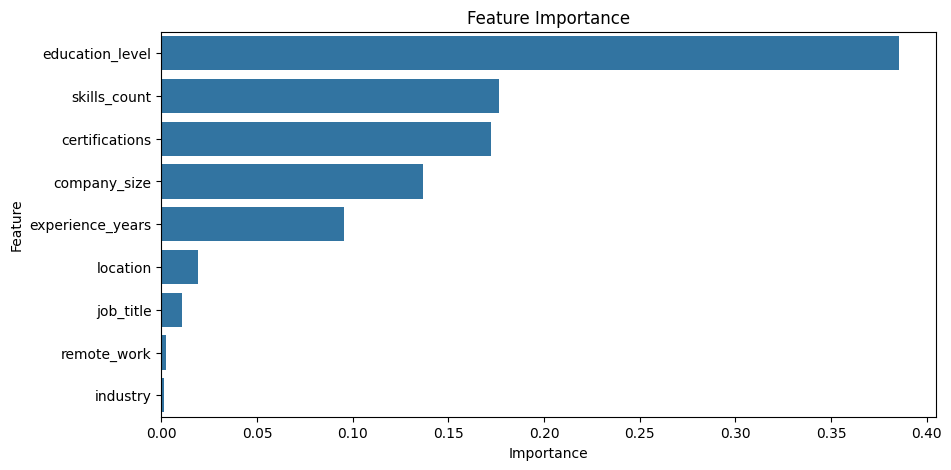

In [56]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_reg.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

**Interpretation:**

*The feature importance plot shows that location is the most influential feature for predicting salary, followed by experience_years, company_size, and job_title. Features such as remote_work, industry, and certifications have a relatively smaller impact on salary prediction.*

**Conclusion:**

*In this project, a Job Salary Prediction model was developed using machine learning techniques. The dataset was successfully loaded, explored, cleaned, and preprocessed before performing Exploratory Data Analysis (EDA). Three machine learning algorithms—**Linear Regression, Decision Tree Regressor, and Random Forest Regressor**—were **trained** and evaluated using performance metrics such as R² Score, MAE, MSE, and RMSE. **Based on the R² score, the Random Forest Regressor achieved the highest accuracy (0.9689), followed by the Decision Tree Regressor (0.9309), while Linear Regression achieved an R² score of 0.4560**.*

*Therefore, **the Random Forest Regressor was selected as the best model for predicting employee salaries**. This project demonstrates the complete machine learning workflow, from data preprocessing and visualization to model building, evaluation, and salary prediction.*